<a href="https://colab.research.google.com/github/julmiha25-sys/MathStatistica/blob/main/%D0%9F%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BA%D0%B0_%D0%BD%D0%B0_%D0%BD%D0%BE%D1%80%D0%BC%D0%B0%D0%BB%D1%8C%D0%BD%D0%BE%D1%81%D1%82%D1%8C/%D0%9F%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BA%D0%B0_%D0%BD%D0%B0_%D0%BD%D0%BE%D1%80%D0%BC%D0%B0%D0%BB%D1%8C%D0%BD%D0%BE%D1%81%D1%82%D1%8C_%D0%BA%D0%BE%D0%BB%D0%B8%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B0_%D1%83%D0%BD%D0%B8%D0%BA%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D1%85_%D0%BF%D0%BE%D1%81%D0%B5%D1%82%D0%B8%D1%82%D0%B5%D0%BB%D0%B5%D0%B9_%D1%81%D0%B0%D0%B9%D1%82%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2167 entries, 0 to 2166
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row                2167 non-null   int64         
 1   Day                2167 non-null   object        
 2   Day.Of.Week        2167 non-null   int64         
 3   Date               2167 non-null   datetime64[ns]
 4   Page.Loads         2167 non-null   object        
 5   Unique.Visits      2167 non-null   float64       
 6   First.Time.Visits  2167 non-null   object        
 7   Returning.Visits   2167 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 135.6+ KB
Медиана:2.938, 
Среднее:13.69983848638671, 
Мода:0    1.197
1    2.667
2    2.780
3    3.039
Name: Unique.Visits, dtype: float64, 
Ср.квадратичное отклонение:97.69151406575013, 
Коэф.асимметрии:9.04032507842706
Макс: 960.0 , Мин: 1.005
МаксДата: 2020-08-19 00:0

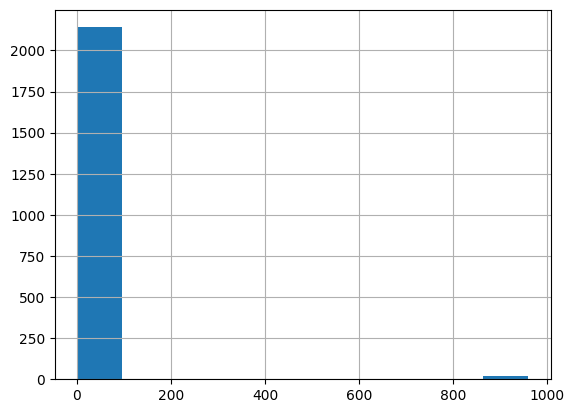

Гистограмма распределения для выборки за 2020 год


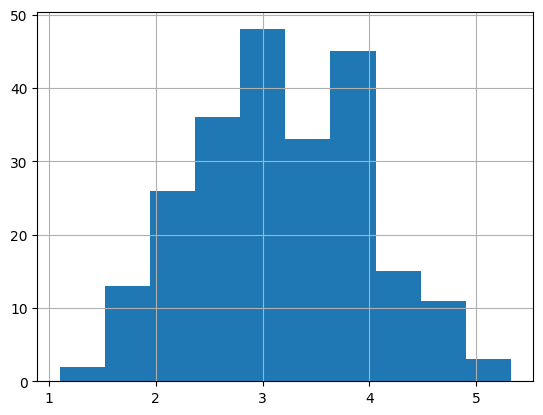

График квантилей  для выборки


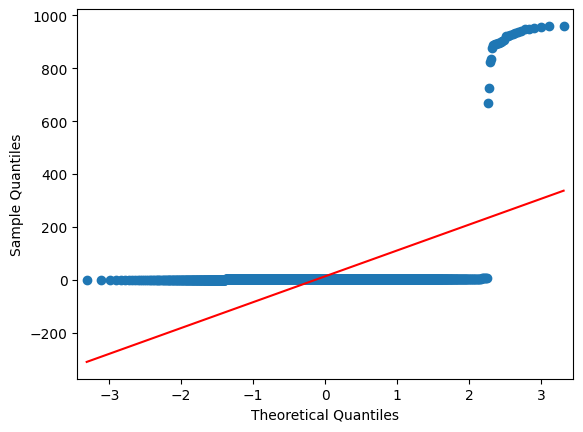

График квантилей  для выборки за 2020 год


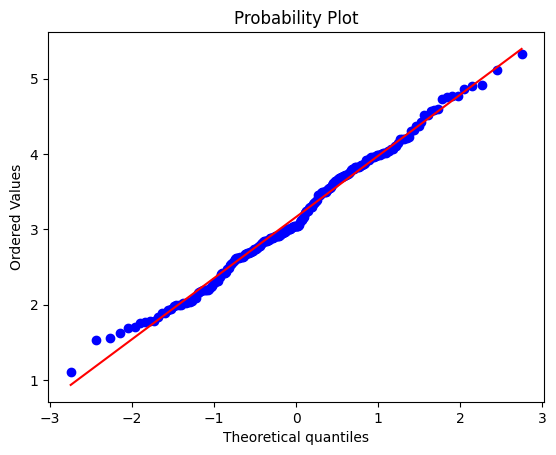

Длина выборки: 2167
Длина выборки за 2020 год: 232
Критерий нормальности Шапиро-Франчиа:ShapiroResult(statistic=np.float64(0.08819404681642029), pvalue=np.float64(8.327454572357515e-73))
Критерий нормальности Шапиро-Франчиа за 2020 год:ShapiroResult(statistic=np.float64(0.9914781886075558), pvalue=np.float64(0.19570025988409195))
Критерий проверки на симметричность:SkewtestResult(statistic=np.float64(48.4206091244419), pvalue=np.float64(0.0))
Критерий проверки на симметричность за 2020 год:SkewtestResult(statistic=np.float64(0.7126231389286983), pvalue=np.float64(0.4760789894674399))
Критерий проверки на симметричность:79.96608691008859, нормальный KurtosistestResult(statistic=np.float64(28.854226408406458), pvalue=np.float64(4.484539673356945e-183))
Критерий проверки на симметричность за 2020 год:-0.46988536908394307, нормальный KurtosistestResult(statistic=np.float64(-1.7288866659810345), pvalue=np.float64(0.08382938096757223))
Критерий К-квадрат Д'Агостино:NormaltestResult(statistic

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import probplot
import scipy.stats as stats
df=pd.read_csv('daily-website-visitors.csv')
df=df.dropna(subset=['Date']).dropna(subset=['Unique.Visits'])
df['Unique.Visits']=df['Unique.Visits'].str.replace(",",".").astype(float)
df['Date']=pd.to_datetime(df['Date'].str.replace("/","."))
df.info()
df1=df['Unique.Visits']
df2=df[df['Date'].dt.year == 2020]['Unique.Visits']
print(f"Медиана:{df1.median()}, \nСреднее:{df1.mean()}, \nМода:{df1.mode()}, \nСр.квадратичное отклонение:{df1.std()}, \nКоэф.асимметрии:{df1.skew()}")
print(f"Макс: {df1.max()} , Мин: {df1.min()}")
print(f"МаксДата: {df['Date'].max()} , МинДата: {df['Date'].min()}")
# У нормального распределения среднее, медиана и мода должны быть близки - у нас нет
# Коэф.ассим. 9>0 - у распределения правый хвост длиннее

# Гистограмма распределения - 2 пика
print("Гистограмма распределения для выборки")
df1.hist(bins=10)
plt.show()
print("Гистограмма распределения для выборки за 2020 год")
df2.hist(bins=10)
plt.show()

# График квантилей - отклонение от нормального вида слишком большие
print("График квантилей  для выборки")
qqplot(df1, line='s')
plt.show()
# График квантилей за 2020 год - отклонение от нормального вида нет
print("График квантилей  для выборки за 2020 год")
stats.probplot(df2, dist="norm", plot=plt)
plt.show()
print(f"Длина выборки: {len(df1)}")
print(f"Длина выборки за 2020 год: {len(df2)}")

# Длина выборки < 5000 - критерий Шапиро-Уилка - Шапиро-Франчиа
from scipy.stats import shapiro
print(f"Критерий нормальности Шапиро-Франчиа:{shapiro(df1)}")
# p=0 < a=0.05 - гипотезу о нормальности выборки отвергаем
print(f"Критерий нормальности Шапиро-Франчиа за 2020 год:{shapiro(df2)}")
# p=0.196 > a=0.05 - гипотезу о нормальности выборки за 2020 год НЕ отвергаем

# Критерий проверки на симметричность
from scipy.stats import *
print(f"Критерий проверки на симметричность:{skewtest(df1)}")
# p=0 < a=0.05 - гипотезу о нормальности выборки отвергаем
print(f"Критерий проверки на симметричность за 2020 год:{skewtest(df2)}")
# p=0.476 > a=0.05 - гипотезу о нормальности выборки за 2020 год НЕ отвергаем

# Критерий проверки на остроту пика
print(f"Критерий проверки на симметричность:{kurtosis(df1)}, нормальный {kurtosistest(df1)}")
# p=0 < a=0.05 - гипотезу о нормальности выборки отвергаем
print(f"Критерий проверки на симметричность за 2020 год:{kurtosis(df2)}, нормальный {kurtosistest(df2)}")
# p=0.084 > a=0.05 - гипотезу о нормальности выборки за 2020 год НЕ отвергаем

# Критерий К-квадрат Д'Агостино
print(f"Критерий К-квадрат Д'Агостино:{normaltest(df1)}")
# p=0 < a=0.05 - гипотезу о нормальности выборки отвергаем
print(f"Критерий К-квадрат Д'Агостино за 2020 год:{normaltest(df2)}")
# p=0.174 > a=0.05 - гипотезу о нормальности выборки за 2020 год НЕ отвергаем

# Тест Андерсона-Дарлинга
print(f"Тест Андерсона-Дарлинга:{anderson(df1)}")
# statistic=807.11 > 0.786 из critical_values=array([0.575, 0.655, 0.786, 0.916, 1.09 ]), соответствующие уровню значимости 0.05 - гипотезу о нормальности выборки отвергаем
print(f"Тест Андерсона-Дарлинга за 2020 год:{anderson(df2)}")
# statistic=0.662 < 0.774 из critical_values=array([0.566, 0.645, 0.774, 0.903, 1.074]), соответствующие уровню значимости 0.05 - гипотезу о нормальности выборки НЕ отвергаем

# Одновыборочный критерий Колмогорова-Смирнова
mean=df1.mean()
std=df1.std()
print(f"Одновыборочный критерий Колмогорова-Смирнова:{ks_1samp(df1, norm.cdf, args=(mean, std))}")
# p=0 < a=0.05 - гипотезу о нормальности выборки отвергаем
mean=df2.mean()
std=df2.std()
print(f"Одновыборочный критерий Колмогорова-Смирнова за 2020 год:{ks_1samp(df2, norm.cdf, args=(mean, std))}")
# p=0.162 > a=0.05 - гипотезу о нормальности выборки за 2020 год НЕ отвергаем


